In [1]:
# ============================================================
# CELL 1 — INSTALL DAN IMPORT LIBRARY
# ============================================================

!pip -q install xgboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
# ============================================================
# CELL 2 — UPLOAD DATASET KE GOOGLE COLAB
# ============================================================

from google.colab import files

uploaded = files.upload()

# Upload dua file berikut:
# 1. NWP(2).csv
# 2. wind farm historical data(2).csv

Saving NWP.csv to NWP.csv
Saving wind farm historical data.csv to wind farm historical data.csv


In [3]:
# ============================================================
# CELL 3 — KONFIGURASI NAMA FILE
# ============================================================

NWP_PATH = "NWP(2).csv"
HIST_PATH = "wind farm historical data(2).csv"

RANDOM_STATE = 42

# Jika Energy pada dataset dianggap sebagai daya/output rata-rata, gunakan mean.
# Jika Energy adalah energi produksi akumulatif per 10 menit, gunakan sum.
ENERGY_AGG = "mean"   # pilihan: "mean" atau "sum"

# Bulan pengujian seperti banyak skenario wind power forecasting
TEST_MONTHS = [10, 11, 12]

# Grid search cukup berat. Jalankan setelah pipeline utama berhasil.
RUN_GRID_SEARCH = False

In [4]:
# ============================================================
# CELL 4 — MEMBACA DATASET
# ============================================================

nwp_raw = pd.read_csv(NWP_PATH)
hist_raw = pd.read_csv(HIST_PATH)

print("NWP shape:", nwp_raw.shape)
print("Historical shape:", hist_raw.shape)

print("\nKolom NWP:")
print(nwp_raw.columns.tolist())

print("\nKolom Historical:")
print(hist_raw.columns.tolist())

display(nwp_raw.head())
display(hist_raw.head())

NWP shape: (8784, 6)
Historical shape: (52704, 4)

Kolom NWP:
['time', 'mod', 'dir', 'temp', 'rh', 'mslp']

Kolom Historical:
['Date', 'Speed', 'Direction', 'Energy']


,time,mod,dir,temp,rh,mslp
0,2016-01-01 01:00:00,7.800498,157.809250,279.174011,0.883095,102120.539062
1,2016-01-01 02:00:00,9.317368,160.928787,279.634003,0.850915,101957.687500
2,2016-01-01 03:00:00,10.075523,164.969742,280.109131,0.821071,101805.640625
3,2016-01-01 04:00:00,10.390824,168.274673,280.268677,0.812411,101717.031250
4,2016-01-01 05:00:00,10.586463,168.172455,280.510437,0.789667,101631.593750


,Date,Speed,Direction,Energy
0,01/01/2016 00:10:00,5.46,144.0,653.56
1,01/01/2016 00:20:00,5.63,147.0,843.89
2,01/01/2016 00:30:00,7.34,146.0,1213.78
3,01/01/2016 00:40:00,6.47,148.0,959.40
4,01/01/2016 00:50:00,6.88,148.0,897.92


In [5]:
# ============================================================
# CELL 5 — PEMERIKSAAN AWAL DATASET
# ============================================================

print("Missing value NWP:")
print(nwp_raw.isna().sum())

print("\nMissing value Historical:")
print(hist_raw.isna().sum())

print("\nInfo NWP:")
display(nwp_raw.describe(include="all"))

print("\nInfo Historical:")
display(hist_raw.describe(include="all"))

Missing value NWP:
time    0
mod     0
dir     0
temp    0
rh      0
mslp    0
dtype: int64

Missing value Historical:
Date           0
Speed        578
Direction    577
Energy       577
dtype: int64

Info NWP:


,time,mod,dir,temp,rh,mslp
count,8784,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
unique,8784,NaN,NaN,NaN,NaN,NaN
top,2016-12-31 08:00:00,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,5.384890,173.689930,284.439158,0.854227,101925.050836
std,NaN,3.004487,95.660569,5.520529,0.147822,815.156392
min,NaN,0.008293,0.028168,270.864075,0.271829,98992.968750
25%,NaN,3.348643,96.702223,280.439270,0.775076,101496.964844
50%,NaN,4.930678,161.365318,283.631378,0.902268,102001.117188
75%,NaN,6.826626,253.818050,287.505852,0.976523,102444.320312



Info Historical:


,Date,Speed,Direction,Energy
count,52704,52126.000000,52127.000000,52127.000000
unique,52704,NaN,NaN,NaN
top,31/12/2016 21:20:00,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,7.019520,169.122892,464.342858
std,NaN,3.124304,99.868826,593.721155
min,NaN,0.350000,0.000000,0.000000
25%,NaN,4.870000,78.000000,2.720000
50%,NaN,6.220000,167.000000,226.840000
75%,NaN,8.280000,252.000000,672.560000


In [6]:
# ============================================================
# CELL 6 — PREPROCESSING DATA NWP
# ============================================================

nwp = nwp_raw.copy()

# Dataset NWP memiliki kolom time, mod, dir, temp, rh, mslp
nwp["time"] = pd.to_datetime(nwp["time"], errors="coerce")

numeric_cols_nwp = ["mod", "dir", "temp", "rh", "mslp"]
for col in numeric_cols_nwp:
    nwp[col] = pd.to_numeric(nwp[col], errors="coerce")

# Hapus baris waktu kosong
nwp = nwp.dropna(subset=["time"])

# Urutkan waktu dan hapus duplikasi timestamp jika ada
nwp = nwp.sort_values("time")
nwp = nwp.drop_duplicates(subset=["time"], keep="first")

# Transformasi arah angin NWP menjadi sin-cos
# Ini penting karena arah angin bersifat circular: 359 derajat dekat dengan 1 derajat
nwp["nwp_dir_sin"] = np.sin(np.deg2rad(nwp["dir"]))
nwp["nwp_dir_cos"] = np.cos(np.deg2rad(nwp["dir"]))

# Rename agar lebih jelas
nwp = nwp.rename(columns={
    "mod": "nwp_wind_speed",
    "temp": "nwp_temp",
    "rh": "nwp_rh",
    "mslp": "nwp_mslp"
})

# Kolom dir asli tidak dipakai karena sudah diubah ke sin-cos
nwp = nwp[[
    "time",
    "nwp_wind_speed",
    "nwp_dir_sin",
    "nwp_dir_cos",
    "nwp_temp",
    "nwp_rh",
    "nwp_mslp"
]]

print("NWP setelah preprocessing:", nwp.shape)
display(nwp.head())
display(nwp.tail())

print("\nRentang waktu NWP:")
print(nwp["time"].min(), "sampai", nwp["time"].max())

NWP setelah preprocessing: (8784, 7)


,time,nwp_wind_speed,nwp_dir_sin,nwp_dir_cos,nwp_temp,nwp_rh,nwp_mslp
0,2016-01-01 01:00:00,7.800498,0.377691,-0.925932,279.174011,0.883095,102120.539062
1,2016-01-01 02:00:00,9.317368,0.326743,-0.945113,279.634003,0.850915,101957.687500
2,2016-01-01 03:00:00,10.075523,0.259329,-0.965789,280.109131,0.821071,101805.640625
3,2016-01-01 04:00:00,10.390824,0.203220,-0.979133,280.268677,0.812411,101717.031250
4,2016-01-01 05:00:00,10.586463,0.204967,-0.978769,280.510437,0.789667,101631.593750


,time,nwp_wind_speed,nwp_dir_sin,nwp_dir_cos,nwp_temp,nwp_rh,nwp_mslp
8779,2016-12-31 20:00:00,0.514760,-0.967805,-0.251700,279.442078,0.795511,102953.664062
8780,2016-12-31 21:00:00,0.732339,-0.992848,-0.119387,278.879120,0.796685,103009.703125
8781,2016-12-31 22:00:00,0.564877,-0.989175,-0.146742,278.353577,0.806703,103020.109375
8782,2016-12-31 23:00:00,0.645025,-0.785132,-0.619329,277.968689,0.816973,102955.546875
8783,2017-01-01 00:00:00,0.662058,-0.452686,-0.891670,277.691437,0.830402,102878.960938



Rentang waktu NWP:
2016-01-01 01:00:00 sampai 2017-01-01 00:00:00


In [7]:
# ============================================================
# CELL 7 — PREPROCESSING DATA HISTORICAL WIND FARM
# ============================================================

hist = hist_raw.copy()

# Dataset historical memiliki kolom Date, Speed, Direction, Energy
# Format tanggal pada file historical umumnya dd/mm/yyyy HH:MM:SS
hist["Date"] = pd.to_datetime(hist["Date"], format="%d/%m/%Y %H:%M:%S", errors="coerce")

for col in ["Speed", "Direction", "Energy"]:
    hist[col] = pd.to_numeric(hist[col], errors="coerce")

hist = hist.dropna(subset=["Date"])
hist = hist.sort_values("Date")
hist = hist.drop_duplicates(subset=["Date"], keep="first")

print("Historical setelah parsing waktu:", hist.shape)
print("Rentang waktu Historical:")
print(hist["Date"].min(), "sampai", hist["Date"].max())

print("\nMissing value setelah parsing:")
print(hist.isna().sum())

display(hist.head())
display(hist.tail())

Historical setelah parsing waktu: (52704, 4)
Rentang waktu Historical:
2016-01-01 00:10:00 sampai 2017-01-01 00:00:00

Missing value setelah parsing:
Date           0
Speed        578
Direction    577
Energy       577
dtype: int64


,Date,Speed,Direction,Energy
0,2016-01-01 00:10:00,5.46,144.0,653.56
1,2016-01-01 00:20:00,5.63,147.0,843.89
2,2016-01-01 00:30:00,7.34,146.0,1213.78
3,2016-01-01 00:40:00,6.47,148.0,959.40
4,2016-01-01 00:50:00,6.88,148.0,897.92


,Date,Speed,Direction,Energy
52699,2016-12-31 23:20:00,5.04,217.0,0.0
52700,2016-12-31 23:30:00,4.88,217.0,0.0
52701,2016-12-31 23:40:00,4.86,216.0,0.0
52702,2016-12-31 23:50:00,4.93,215.0,0.0
52703,2017-01-01 00:00:00,4.87,207.0,0.0


In [8]:
# ============================================================
# CELL 8 — RESAMPLING HISTORICAL 10 MENIT MENJADI HOURLY
# ============================================================

hist_hourly = hist.copy()

# Transformasi arah angin aktual menjadi sin-cos sebelum resampling
hist_hourly["hist_dir_sin"] = np.sin(np.deg2rad(hist_hourly["Direction"]))
hist_hourly["hist_dir_cos"] = np.cos(np.deg2rad(hist_hourly["Direction"]))

hist_hourly = hist_hourly.set_index("Date")

agg_dict = {
    "Speed": "mean",
    "hist_dir_sin": "mean",
    "hist_dir_cos": "mean",
    "Energy": ENERGY_AGG
}

# label='right' dan closed='right' berarti:
# data 00:10, 00:20, ..., 01:00 akan diberi label 01:00
# sehingga cocok dengan timestamp NWP per jam
hist_hourly = (
    hist_hourly
    .resample("1H", label="right", closed="right")
    .agg(agg_dict)
    .reset_index()
)

hist_hourly = hist_hourly.rename(columns={
    "Date": "time",
    "Speed": "hist_wind_speed",
    "Energy": "energy"
})

print("Historical hourly:", hist_hourly.shape)
print("Rentang waktu Historical hourly:")
print(hist_hourly["time"].min(), "sampai", hist_hourly["time"].max())

print("\nMissing value Historical hourly:")
print(hist_hourly.isna().sum())

display(hist_hourly.head())
display(hist_hourly.tail())

Historical hourly: (8784, 5)
Rentang waktu Historical hourly:
2016-01-01 01:00:00 sampai 2017-01-01 00:00:00

Missing value Historical hourly:
time                0
hist_wind_speed    93
hist_dir_sin       93
hist_dir_cos       93
energy             93
dtype: int64


,time,hist_wind_speed,hist_dir_sin,hist_dir_cos,energy
0,2016-01-01 01:00:00,6.541667,0.549349,-0.835249,948.085000
1,2016-01-01 02:00:00,8.281667,0.582580,-0.811732,1290.335000
2,2016-01-01 03:00:00,7.345000,0.566327,-0.824011,1276.750000
3,2016-01-01 04:00:00,10.988333,0.650624,-0.757283,1621.746667
4,2016-01-01 05:00:00,11.220000,0.692166,-0.720935,1628.595000


,time,hist_wind_speed,hist_dir_sin,hist_dir_cos,energy
8779,2016-12-31 20:00:00,4.740000,0.126212,-0.981761,0.0
8780,2016-12-31 21:00:00,4.838333,-0.008721,-0.997489,0.0
8781,2016-12-31 22:00:00,5.465000,-0.446081,-0.881015,0.0
8782,2016-12-31 23:00:00,4.871667,-0.617473,-0.785597,0.0
8783,2017-01-01 00:00:00,4.923333,-0.570133,-0.819180,0.0


In [9]:
# ============================================================
# CELL 9 — MERGE NWP DAN HISTORICAL HOURLY
# ============================================================

data = pd.merge(nwp, hist_hourly, on="time", how="inner")
data = data.sort_values("time").reset_index(drop=True)

print("Data setelah merge:", data.shape)
print("Rentang waktu data merge:")
print(data["time"].min(), "sampai", data["time"].max())

print("\nMissing value setelah merge:")
print(data.isna().sum())

display(data.head())
display(data.tail())

Data setelah merge: (8784, 11)
Rentang waktu data merge:
2016-01-01 01:00:00 sampai 2017-01-01 00:00:00

Missing value setelah merge:
time                0
nwp_wind_speed      0
nwp_dir_sin         0
nwp_dir_cos         0
nwp_temp            0
nwp_rh              0
nwp_mslp            0
hist_wind_speed    93
hist_dir_sin       93
hist_dir_cos       93
energy             93
dtype: int64


,time,nwp_wind_speed,nwp_dir_sin,nwp_dir_cos,nwp_temp,nwp_rh,nwp_mslp,hist_wind_speed,hist_dir_sin,hist_dir_cos,energy
0,2016-01-01 01:00:00,7.800498,0.377691,-0.925932,279.174011,0.883095,102120.539062,6.541667,0.549349,-0.835249,948.085000
1,2016-01-01 02:00:00,9.317368,0.326743,-0.945113,279.634003,0.850915,101957.687500,8.281667,0.582580,-0.811732,1290.335000
2,2016-01-01 03:00:00,10.075523,0.259329,-0.965789,280.109131,0.821071,101805.640625,7.345000,0.566327,-0.824011,1276.750000
3,2016-01-01 04:00:00,10.390824,0.203220,-0.979133,280.268677,0.812411,101717.031250,10.988333,0.650624,-0.757283,1621.746667
4,2016-01-01 05:00:00,10.586463,0.204967,-0.978769,280.510437,0.789667,101631.593750,11.220000,0.692166,-0.720935,1628.595000


,time,nwp_wind_speed,nwp_dir_sin,nwp_dir_cos,nwp_temp,nwp_rh,nwp_mslp,hist_wind_speed,hist_dir_sin,hist_dir_cos,energy
8779,2016-12-31 20:00:00,0.514760,-0.967805,-0.251700,279.442078,0.795511,102953.664062,4.740000,0.126212,-0.981761,0.0
8780,2016-12-31 21:00:00,0.732339,-0.992848,-0.119387,278.879120,0.796685,103009.703125,4.838333,-0.008721,-0.997489,0.0
8781,2016-12-31 22:00:00,0.564877,-0.989175,-0.146742,278.353577,0.806703,103020.109375,5.465000,-0.446081,-0.881015,0.0
8782,2016-12-31 23:00:00,0.645025,-0.785132,-0.619329,277.968689,0.816973,102955.546875,4.871667,-0.617473,-0.785597,0.0
8783,2017-01-01 00:00:00,0.662058,-0.452686,-0.891670,277.691437,0.830402,102878.960938,4.923333,-0.570133,-0.819180,0.0


In [10]:
# ============================================================
# CELL 10 — PENANGANAN MISSING VALUE
# ============================================================

# Untuk time series, missing value panjang sebaiknya tidak diisi sembarangan.
# Strategi aman:
# - interpolasi hanya untuk gap pendek
# - baris yang masih kosong setelah interpolasi dihapus

data = data.copy()
data = data.set_index("time")

# Interpolasi berbasis waktu untuk gap pendek maksimal 3 jam
cols_to_interpolate = [
    "hist_wind_speed",
    "hist_dir_sin",
    "hist_dir_cos",
    "energy"
]

data[cols_to_interpolate] = data[cols_to_interpolate].interpolate(
    method="time",
    limit=3,
    limit_direction="both"
)

# Untuk fitur NWP, jika ada missing pendek, gunakan forward/backward fill
nwp_feature_cols = [
    "nwp_wind_speed",
    "nwp_dir_sin",
    "nwp_dir_cos",
    "nwp_temp",
    "nwp_rh",
    "nwp_mslp"
]

data[nwp_feature_cols] = data[nwp_feature_cols].ffill().bfill()

# Hapus baris yang masih memiliki missing value
data = data.dropna()

data = data.reset_index()

print("Data setelah penanganan missing value:", data.shape)
print("\nMissing value final:")
print(data.isna().sum())

display(data.head())
display(data.tail())

Data setelah penanganan missing value: (8710, 11)

Missing value final:
time               0
nwp_wind_speed     0
nwp_dir_sin        0
nwp_dir_cos        0
nwp_temp           0
nwp_rh             0
nwp_mslp           0
hist_wind_speed    0
hist_dir_sin       0
hist_dir_cos       0
energy             0
dtype: int64


,time,nwp_wind_speed,nwp_dir_sin,nwp_dir_cos,nwp_temp,nwp_rh,nwp_mslp,hist_wind_speed,hist_dir_sin,hist_dir_cos,energy
0,2016-01-01 01:00:00,7.800498,0.377691,-0.925932,279.174011,0.883095,102120.539062,6.541667,0.549349,-0.835249,948.085000
1,2016-01-01 02:00:00,9.317368,0.326743,-0.945113,279.634003,0.850915,101957.687500,8.281667,0.582580,-0.811732,1290.335000
2,2016-01-01 03:00:00,10.075523,0.259329,-0.965789,280.109131,0.821071,101805.640625,7.345000,0.566327,-0.824011,1276.750000
3,2016-01-01 04:00:00,10.390824,0.203220,-0.979133,280.268677,0.812411,101717.031250,10.988333,0.650624,-0.757283,1621.746667
4,2016-01-01 05:00:00,10.586463,0.204967,-0.978769,280.510437,0.789667,101631.593750,11.220000,0.692166,-0.720935,1628.595000


,time,nwp_wind_speed,nwp_dir_sin,nwp_dir_cos,nwp_temp,nwp_rh,nwp_mslp,hist_wind_speed,hist_dir_sin,hist_dir_cos,energy
8705,2016-12-31 20:00:00,0.514760,-0.967805,-0.251700,279.442078,0.795511,102953.664062,4.740000,0.126212,-0.981761,0.0
8706,2016-12-31 21:00:00,0.732339,-0.992848,-0.119387,278.879120,0.796685,103009.703125,4.838333,-0.008721,-0.997489,0.0
8707,2016-12-31 22:00:00,0.564877,-0.989175,-0.146742,278.353577,0.806703,103020.109375,5.465000,-0.446081,-0.881015,0.0
8708,2016-12-31 23:00:00,0.645025,-0.785132,-0.619329,277.968689,0.816973,102955.546875,4.871667,-0.617473,-0.785597,0.0
8709,2017-01-01 00:00:00,0.662058,-0.452686,-0.891670,277.691437,0.830402,102878.960938,4.923333,-0.570133,-0.819180,0.0


In [11]:
# ============================================================
# CELL 11 — FEATURE ENGINEERING TIME SERIES
# ============================================================

df = data.copy()
df = df.sort_values("time").reset_index(drop=True)

# Fitur waktu
df["hour"] = df["time"].dt.hour
df["dayofweek"] = df["time"].dt.dayofweek
df["month"] = df["time"].dt.month
df["dayofyear"] = df["time"].dt.dayofyear

# Transformasi waktu menjadi sin-cos agar pola siklik tidak dianggap linear
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Lag fitur target energy
# shift(1) dipakai agar nilai energy pada waktu t tidak bocor menjadi fitur untuk memprediksi waktu t
for lag in [1, 2, 3, 6, 12, 24]:
    df[f"energy_lag_{lag}"] = df["energy"].shift(lag)

# Lag fitur kecepatan angin aktual
for lag in [1, 2, 3, 6, 12, 24]:
    df[f"hist_wind_speed_lag_{lag}"] = df["hist_wind_speed"].shift(lag)

# Rolling statistics target energy
# shift(1) wajib agar tidak terjadi data leakage
for window in [3, 6, 12, 24]:
    df[f"energy_roll_mean_{window}"] = df["energy"].shift(1).rolling(window=window).mean()
    df[f"energy_roll_std_{window}"] = df["energy"].shift(1).rolling(window=window).std()

# Rolling statistics historical wind speed
for window in [3, 6, 12, 24]:
    df[f"hist_wind_speed_roll_mean_{window}"] = df["hist_wind_speed"].shift(1).rolling(window=window).mean()
    df[f"hist_wind_speed_roll_std_{window}"] = df["hist_wind_speed"].shift(1).rolling(window=window).std()

# Hapus baris awal yang kosong akibat lag dan rolling
df = df.dropna().reset_index(drop=True)

print("Data final setelah feature engineering:", df.shape)
display(df.head())

Data final setelah feature engineering: (8686, 47)


,time,nwp_wind_speed,nwp_dir_sin,nwp_dir_cos,nwp_temp,nwp_rh,nwp_mslp,hist_wind_speed,hist_dir_sin,hist_dir_cos,energy,hour,dayofweek,month,dayofyear,hour_sin,hour_cos,month_sin,month_cos,energy_lag_1,energy_lag_2,energy_lag_3,energy_lag_6,energy_lag_12,energy_lag_24,hist_wind_speed_lag_1,hist_wind_speed_lag_2,hist_wind_speed_lag_3,hist_wind_speed_lag_6,hist_wind_speed_lag_12,hist_wind_speed_lag_24,energy_roll_mean_3,energy_roll_std_3,energy_roll_mean_6,energy_roll_std_6,energy_roll_mean_12,energy_roll_std_12,energy_roll_mean_24,energy_roll_std_24,hist_wind_speed_roll_mean_3,hist_wind_speed_roll_std_3,hist_wind_speed_roll_mean_6,hist_wind_speed_roll_std_6,hist_wind_speed_roll_mean_12,hist_wind_speed_roll_std_12,hist_wind_speed_roll_mean_24,hist_wind_speed_roll_std_24
0,2016-01-02 01:00:00,7.931810,-0.897900,-0.440200,278.463074,0.900087,101708.078125,14.718333,-0.804777,-0.591894,2073.963333,1,5,1,2,0.258819,0.965926,0.5,0.866025,2239.518333,2311.898333,2131.635000,2424.405000,2250.900000,948.085000,13.691667,14.750000,12.978333,14.946667,15.301667,6.541667,2227.683889,90.712501,2229.531944,120.325539,2319.829861,144.582055,1948.656875,449.062194,13.806667,0.891414,14.194167,0.750446,15.384028,1.452615,12.958125,3.127293
1,2016-01-02 02:00:00,8.368614,-0.898618,-0.438733,278.521820,0.891638,101728.656250,13.870000,-0.876038,-0.472424,2021.706667,2,5,1,2,0.500000,0.866025,0.5,0.866025,2073.963333,2239.518333,2311.898333,2138.416667,2476.161667,1290.335000,14.718333,13.691667,14.750000,14.650000,17.386667,8.281667,2208.460000,121.970206,2171.125000,87.348766,2305.085139,160.406818,1995.568472,395.619961,14.386667,0.602096,14.156111,0.709317,15.335417,1.465326,13.298819,2.829048
2,2016-01-02 03:00:00,8.628706,-0.935068,-0.354469,278.824310,0.874632,101724.117188,13.540000,-0.922835,-0.369738,1843.596667,3,5,1,2,0.707107,0.707107,0.5,0.866025,2021.706667,2073.963333,2239.518333,2131.318333,2305.886667,1276.750000,13.870000,14.718333,13.691667,14.148333,17.055000,7.345000,2111.729444,113.710993,2151.673333,106.896992,2267.213889,169.721489,2026.042292,365.994167,14.093333,0.548561,14.026111,0.671146,15.042361,1.366090,13.531667,2.620437
3,2016-01-02 04:00:00,9.833473,-0.895500,-0.445061,278.711761,0.878763,101768.742188,11.323333,-0.878339,-0.476895,1507.420000,4,5,1,2,0.866025,0.500000,0.5,0.866025,1843.596667,2021.706667,2073.963333,2131.635000,2513.445000,1621.746667,13.540000,13.870000,14.718333,12.978333,16.315000,10.988333,1979.755556,120.777159,2103.719722,166.032797,2228.689722,208.240650,2049.660903,332.274711,14.042778,0.607870,13.924722,0.694532,14.749444,1.268679,13.789792,2.265623
4,2016-01-02 05:00:00,8.036910,-0.985837,-0.167704,278.312866,0.918632,101819.703125,10.565000,-0.826392,-0.557313,1391.286667,5,5,1,2,0.965926,0.258819,0.5,0.866025,1507.420000,1843.596667,2021.706667,2311.898333,2502.043333,1628.595000,11.323333,13.540000,13.870000,14.750000,17.325000,11.220000,1790.907778,261.160455,1999.683889,292.468055,2144.854306,274.989218,2044.897292,339.418885,12.911111,1.384920,13.648889,1.251155,14.333472,1.505018,13.803750,2.248581


In [12]:
# ============================================================
# CELL 12 — DAFTAR FITUR DAN TARGET
# ============================================================

target_col = "energy"

drop_cols = [
    "time",
    "energy",
    "hour",
    "dayofweek",
    "month",
    "dayofyear"
]

feature_cols = [col for col in df.columns if col not in drop_cols]

print("Jumlah fitur:", len(feature_cols))
print("Target:", target_col)

print("\nDaftar fitur:")
for col in feature_cols:
    print("-", col)

Jumlah fitur: 41
Target: energy

Daftar fitur:
- nwp_wind_speed
- nwp_dir_sin
- nwp_dir_cos
- nwp_temp
- nwp_rh
- nwp_mslp
- hist_wind_speed
- hist_dir_sin
- hist_dir_cos
- hour_sin
- hour_cos
- month_sin
- month_cos
- energy_lag_1
- energy_lag_2
- energy_lag_3
- energy_lag_6
- energy_lag_12
- energy_lag_24
- hist_wind_speed_lag_1
- hist_wind_speed_lag_2
- hist_wind_speed_lag_3
- hist_wind_speed_lag_6
- hist_wind_speed_lag_12
- hist_wind_speed_lag_24
- energy_roll_mean_3
- energy_roll_std_3
- energy_roll_mean_6
- energy_roll_std_6
- energy_roll_mean_12
- energy_roll_std_12
- energy_roll_mean_24
- energy_roll_std_24
- hist_wind_speed_roll_mean_3
- hist_wind_speed_roll_std_3
- hist_wind_speed_roll_mean_6
- hist_wind_speed_roll_std_6
- hist_wind_speed_roll_mean_12
- hist_wind_speed_roll_std_12
- hist_wind_speed_roll_mean_24
- hist_wind_speed_roll_std_24


In [13]:
# ============================================================
# CELL 13 — FUNGSI EVALUASI MODEL
# ============================================================

def regression_metrics(y_true, y_pred):
    rmse_value = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_value = mean_absolute_error(y_true, y_pred)
    r2_value = r2_score(y_true, y_pred)

    # MAPE hanya dihitung untuk y_true yang tidak nol
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    non_zero_mask = y_true_arr != 0

    if non_zero_mask.sum() > 0:
        mape_value = np.mean(
            np.abs((y_true_arr[non_zero_mask] - y_pred_arr[non_zero_mask]) / y_true_arr[non_zero_mask])
        ) * 100
    else:
        mape_value = np.nan

    return {
        "RMSE": rmse_value,
        "MAE": mae_value,
        "MAPE": mape_value,
        "R2": r2_value
    }


def print_metrics(name, metrics):
    print(name)
    print("RMSE :", round(metrics["RMSE"], 6))
    print("MAE  :", round(metrics["MAE"], 6))
    print("MAPE :", round(metrics["MAPE"], 6))
    print("R2   :", round(metrics["R2"], 6))

In [14]:
# ============================================================
# CELL 14 — BASELINE NAIVE LAG-1
# ============================================================

# Baseline sederhana:
# prediksi energy pada waktu t = energy pada waktu t-1
# Ini penting agar model machine learning dibandingkan dengan baseline minimum.

baseline_results = []

for test_month in TEST_MONTHS:
    test_mask = df["time"].dt.month == test_month
    train_mask = df["time"] < df.loc[test_mask, "time"].min()

    test_df = df.loc[test_mask].copy()

    y_test = test_df[target_col]
    y_pred_naive = test_df["energy_lag_1"]

    metrics = regression_metrics(y_test, y_pred_naive)

    baseline_results.append({
        "Scenario": f"Test Month {test_month}",
        "Model": "Naive Lag-1",
        **metrics
    })

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df)

,Scenario,Model,RMSE,MAE,MAPE,R2
0,Test Month 10,Naive Lag-1,149.368569,86.500134,23200.972173,0.807553
1,Test Month 11,Naive Lag-1,193.066575,127.444789,13920.808698,0.899767
2,Test Month 12,Naive Lag-1,163.820900,101.491366,8950.884064,0.827856


In [15]:
# ============================================================
# CELL 15 — XGBOOST BASELINE UNTUK SETIAP BULAN UJI
# ============================================================

xgb_baseline_results = []
predictions_store = {}

for test_month in TEST_MONTHS:
    print("=" * 80)
    print(f"SKENARIO UJI BULAN {test_month}")

    test_mask = df["time"].dt.month == test_month

    if test_mask.sum() == 0:
        print(f"Tidak ada data untuk bulan {test_month}")
        continue

    test_start_time = df.loc[test_mask, "time"].min()
    train_mask = df["time"] < test_start_time

    train_df = df.loc[train_mask].copy()
    test_df = df.loc[test_mask].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    print("Train period:", train_df["time"].min(), "sampai", train_df["time"].max())
    print("Test period :", test_df["time"].min(), "sampai", test_df["time"].max())
    print("Train shape :", X_train.shape)
    print("Test shape  :", X_test.shape)

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = regression_metrics(y_test, y_pred)
    print_metrics("XGBoost Baseline", metrics)

    xgb_baseline_results.append({
        "Scenario": f"Test Month {test_month}",
        "Model": "XGBoost Baseline",
        "Train_Size": len(train_df),
        "Test_Size": len(test_df),
        **metrics
    })

    predictions_store[f"month_{test_month}_xgb_baseline"] = pd.DataFrame({
        "time": test_df["time"].values,
        "actual": y_test.values,
        "predicted": y_pred
    })

xgb_baseline_results_df = pd.DataFrame(xgb_baseline_results)
display(xgb_baseline_results_df)

SKENARIO UJI BULAN 10
Train period: 2016-01-02 01:00:00 sampai 2016-09-30 23:00:00
Test period : 2016-10-01 00:00:00 sampai 2016-10-31 23:00:00
Train shape : (6477, 41)
Test shape  : (744, 41)
XGBoost Baseline
RMSE : 82.552055
MAE  : 52.97722
MAPE : 27086.839156
R2   : 0.941217
SKENARIO UJI BULAN 11
Train period: 2016-01-02 01:00:00 sampai 2016-10-31 23:00:00
Test period : 2016-11-01 00:00:00 sampai 2016-11-30 23:00:00
Train shape : (7221, 41)
Test shape  : (720, 41)
XGBoost Baseline
RMSE : 120.596648
MAE  : 79.143699
MAPE : 10638.597439
R2   : 0.960892
SKENARIO UJI BULAN 12
Train period: 2016-01-02 01:00:00 sampai 2016-11-30 23:00:00
Test period : 2016-12-01 00:00:00 sampai 2016-12-31 23:00:00
Train shape : (7941, 41)
Test shape  : (744, 41)
XGBoost Baseline
RMSE : 113.242341
MAE  : 74.680576
MAPE : 13289.0079
R2   : 0.917743


,Scenario,Model,Train_Size,Test_Size,RMSE,MAE,MAPE,R2
0,Test Month 10,XGBoost Baseline,6477,744,82.552055,52.977220,27086.839156,0.941217
1,Test Month 11,XGBoost Baseline,7221,720,120.596648,79.143699,10638.597439,0.960892
2,Test Month 12,XGBoost Baseline,7941,744,113.242341,74.680576,13289.007900,0.917743


In [16]:
# ============================================================
# CELL 16 — RANDOMIZED SEARCH XGBOOST
# ============================================================

xgb_random_results = []
best_models = {}

param_distributions = {
    "n_estimators": [300, 500, 700, 900],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_lambda": [0.1, 1.0, 5.0, 10.0],
    "reg_alpha": [0.0, 0.01, 0.1, 1.0]
}

for test_month in TEST_MONTHS:
    print("=" * 80)
    print(f"RANDOMIZED SEARCH — SKENARIO UJI BULAN {test_month}")

    test_mask = df["time"].dt.month == test_month

    if test_mask.sum() == 0:
        print(f"Tidak ada data untuk bulan {test_month}")
        continue

    test_start_time = df.loc[test_mask, "time"].min()
    train_mask = df["time"] < test_start_time

    train_df = df.loc[train_mask].copy()
    test_df = df.loc[test_mask].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    base_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # TimeSeriesSplit agar validasi tidak acak
    tscv = TimeSeriesSplit(n_splits=3)

    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=20,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        verbose=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)

    metrics = regression_metrics(y_test, y_pred)

    print("Best params:")
    print(random_search.best_params_)
    print_metrics("XGBoost RandomizedSearchCV", metrics)

    xgb_random_results.append({
        "Scenario": f"Test Month {test_month}",
        "Model": "XGBoost RandomizedSearchCV",
        "Train_Size": len(train_df),
        "Test_Size": len(test_df),
        "Best_Params": random_search.best_params_,
        **metrics
    })

    best_models[f"month_{test_month}"] = best_model

    predictions_store[f"month_{test_month}_xgb_random"] = pd.DataFrame({
        "time": test_df["time"].values,
        "actual": y_test.values,
        "predicted": y_pred
    })

xgb_random_results_df = pd.DataFrame(xgb_random_results)
display(xgb_random_results_df)

RANDOMIZED SEARCH — SKENARIO UJI BULAN 10
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params:
{'subsample': 0.9, 'reg_lambda': 10.0, 'reg_alpha': 0.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
XGBoost RandomizedSearchCV
RMSE : 85.174778
MAE  : 55.053252
MAPE : 26820.065242
R2   : 0.937423
RANDOMIZED SEARCH — SKENARIO UJI BULAN 11
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params:
{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
XGBoost RandomizedSearchCV
RMSE : 120.506769
MAE  : 80.322553
MAPE : 13230.966095
R2   : 0.96095
RANDOMIZED SEARCH — SKENARIO UJI BULAN 12
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params:
{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
XGBoost RandomizedSearchCV
RMSE :

,Scenario,Model,Train_Size,Test_Size,Best_Params,RMSE,MAE,MAPE,R2
0,Test Month 10,XGBoost RandomizedSearchCV,6477,744,"{'subsample': 0.9, 'reg_lambda': 10.0, 'reg_al...",85.174778,55.053252,26820.065242,0.937423
1,Test Month 11,XGBoost RandomizedSearchCV,7221,720,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",120.506769,80.322553,13230.966095,0.960950
2,Test Month 12,XGBoost RandomizedSearchCV,7941,744,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp...",116.955179,77.905105,13435.527514,0.912261


In [19]:
# ============================================================
# CELL 17 — GRID SEARCH OPSIONAL
# ============================================================

xgb_grid_results = []

if RUN_GRID_SEARCH:
    for test_month in TEST_MONTHS:
        print("=" * 80)
        print(f"GRID SEARCH — SKENARIO UJI BULAN {test_month}")

        test_mask = df["time"].dt.month == test_month

        if test_mask.sum() == 0:
            print(f"Tidak ada data untuk bulan {test_month}")
            continue

        test_start_time = df.loc[test_mask, "time"].min()
        train_mask = df["time"] < test_start_time

        train_df = df.loc[train_mask].copy()
        test_df = df.loc[test_mask].copy()

        X_train = train_df[feature_cols]
        y_train = train_df[target_col]

        X_test = test_df[feature_cols]
        y_test = test_df[target_col]

        # Ambil parameter terbaik Random Search sebagai titik awal
        if f"month_{test_month}" in best_models:
            random_best_params = best_models[f"month_{test_month}"].get_params()
        else:
            random_best_params = {
                "max_depth": 4,
                "learning_rate": 0.03,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
                "reg_lambda": 1.0,
                "reg_alpha": 0.0
            }

        grid_params = {
            "n_estimators": [300, 500, 700],
            "max_depth": [max(2, random_best_params.get("max_depth", 4) - 1),
                          random_best_params.get("max_depth", 4),
                          random_best_params.get("max_depth", 4) + 1],
            "learning_rate": [0.01, 0.03, 0.05],
            "subsample": [0.8, 0.9, 1.0],
            "colsample_bytree": [0.8, 0.9, 1.0],
            "reg_lambda": [0.1, 1.0, 5.0],
            "reg_alpha": [0.0, 0.01, 0.1]
        }

        base_model = XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        tscv = TimeSeriesSplit(n_splits=3)

        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=grid_params,
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            verbose=1,
            n_jobs=-1
        )

        grid_search.fit(X_train, y_train)

        best_grid_model = grid_search.best_estimator_
        y_pred = best_grid_model.predict(X_test)

        metrics = regression_metrics(y_test, y_pred)

        print("Best Grid Params:")
        print(grid_search.best_params_)
        print_metrics("XGBoost GridSearchCV", metrics)

        xgb_grid_results.append({
            "Scenario": f"Test Month {test_month}",
            "Model": "XGBoost GridSearchCV",
            "Train_Size": len(train_df),
            "Test_Size": len(test_df),
            "Best_Params": grid_search.best_params_,
            **metrics
        })

        predictions_store[f"month_{test_month}_xgb_grid"] = pd.DataFrame({
            "time": test_df["time"].values,
            "actual": y_test.values,
            "predicted": y_pred
        })

else:
    print("Grid Search tidak dijalankan.")
    print("Jika ingin menjalankan, ubah RUN_GRID_SEARCH = True pada CELL 3.")

xgb_grid_results_df = pd.DataFrame(xgb_grid_results)
display(xgb_grid_results_df)

Grid Search tidak dijalankan.
Jika ingin menjalankan, ubah RUN_GRID_SEARCH = True pada CELL 3.


""


In [20]:
# ============================================================
# CELL 18 — GABUNGKAN SEMUA HASIL EVALUASI
# ============================================================

result_tables = [
    baseline_results_df,
    xgb_baseline_results_df,
    xgb_random_results_df
]

if RUN_GRID_SEARCH and len(xgb_grid_results_df) > 0:
    result_tables.append(xgb_grid_results_df)

all_results = pd.concat(result_tables, ignore_index=True)

# Urutkan kolom agar rapi
ordered_cols = [
    "Scenario",
    "Model",
    "Train_Size",
    "Test_Size",
    "RMSE",
    "MAE",
    "MAPE",
    "R2",
    "Best_Params"
]

for col in ordered_cols:
    if col not in all_results.columns:
        all_results[col] = np.nan

all_results = all_results[ordered_cols]

display(all_results)

# Simpan hasil ke CSV
all_results.to_csv("wind_power_forecasting_results.csv", index=False)

print("File hasil evaluasi disimpan sebagai: wind_power_forecasting_results.csv")

,Scenario,Model,Train_Size,Test_Size,RMSE,MAE,MAPE,R2,Best_Params
0,Test Month 10,Naive Lag-1,NaN,NaN,149.368569,86.500134,23200.972173,0.807553,NaN
1,Test Month 11,Naive Lag-1,NaN,NaN,193.066575,127.444789,13920.808698,0.899767,NaN
2,Test Month 12,Naive Lag-1,NaN,NaN,163.820900,101.491366,8950.884064,0.827856,NaN
3,Test Month 10,XGBoost Baseline,6477.0,744.0,82.552055,52.977220,27086.839156,0.941217,NaN
4,Test Month 11,XGBoost Baseline,7221.0,720.0,120.596648,79.143699,10638.597439,0.960892,NaN
5,Test Month 12,XGBoost Baseline,7941.0,744.0,113.242341,74.680576,13289.007900,0.917743,NaN
6,Test Month 10,XGBoost RandomizedSearchCV,6477.0,744.0,85.174778,55.053252,26820.065242,0.937423,"{'subsample': 0.9, 'reg_lambda': 10.0, 'reg_al..."
7,Test Month 11,XGBoost RandomizedSearchCV,7221.0,720.0,120.506769,80.322553,13230.966095,0.960950,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp..."
8,Test Month 12,XGBoost RandomizedSearchCV,7941.0,744.0,116.955179,77.905105,13435.527514,0.912261,"{'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alp..."


File hasil evaluasi disimpan sebagai: wind_power_forecasting_results.csv


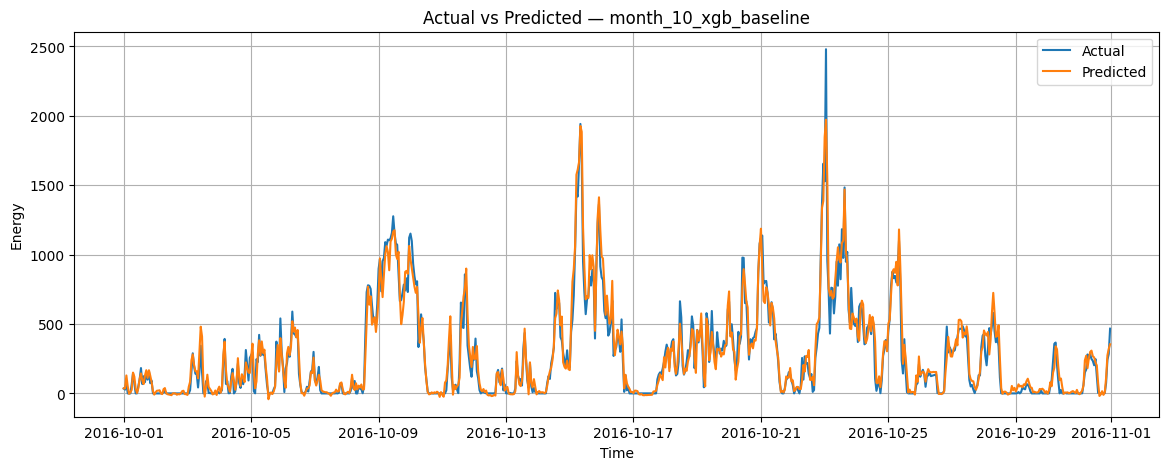

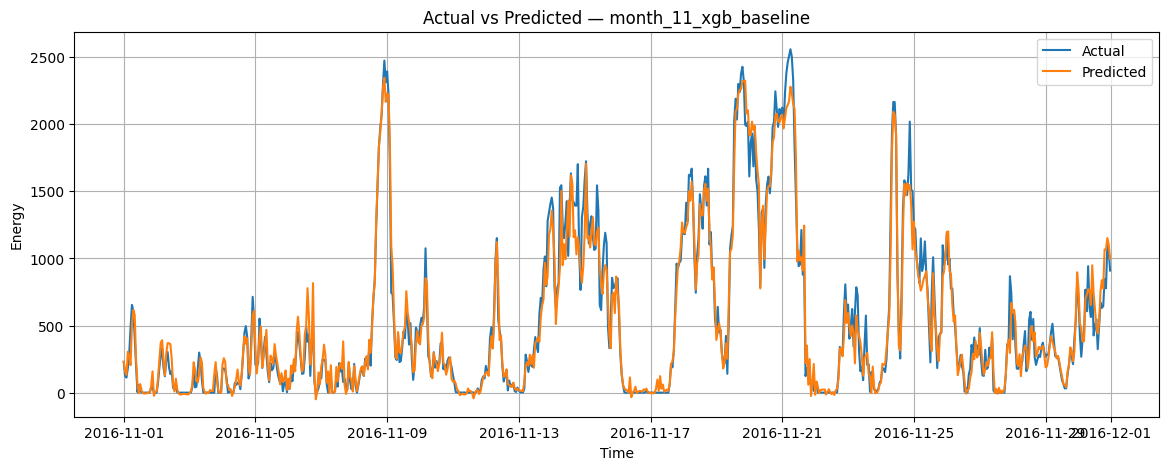

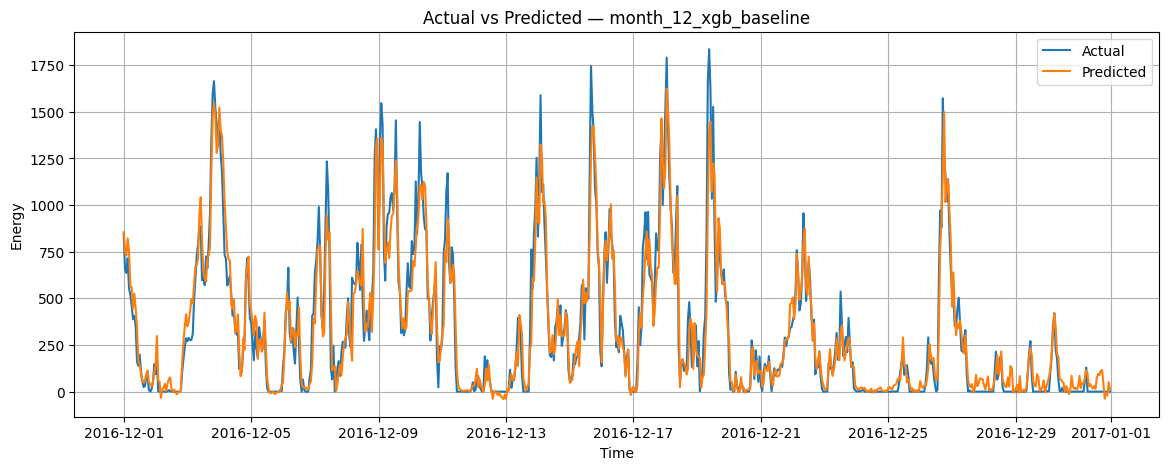

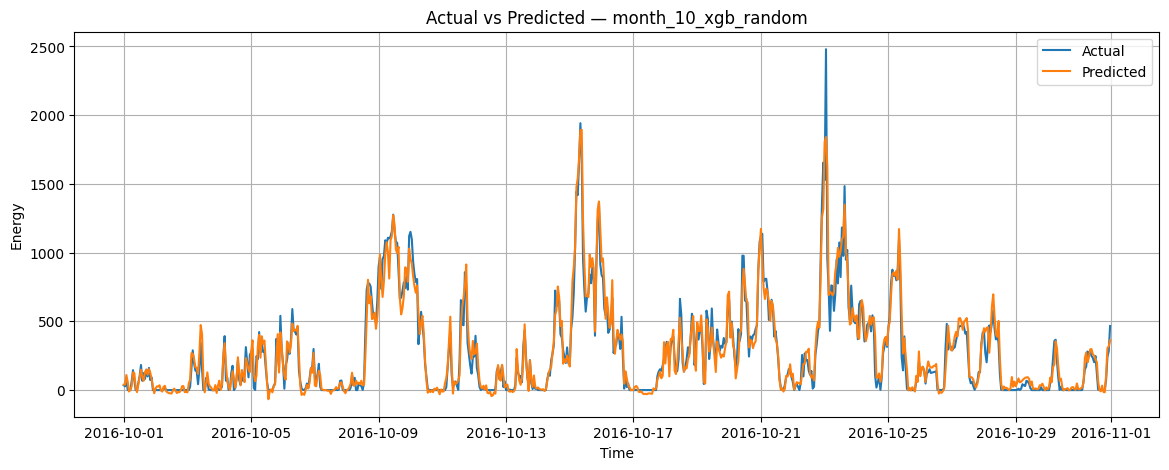

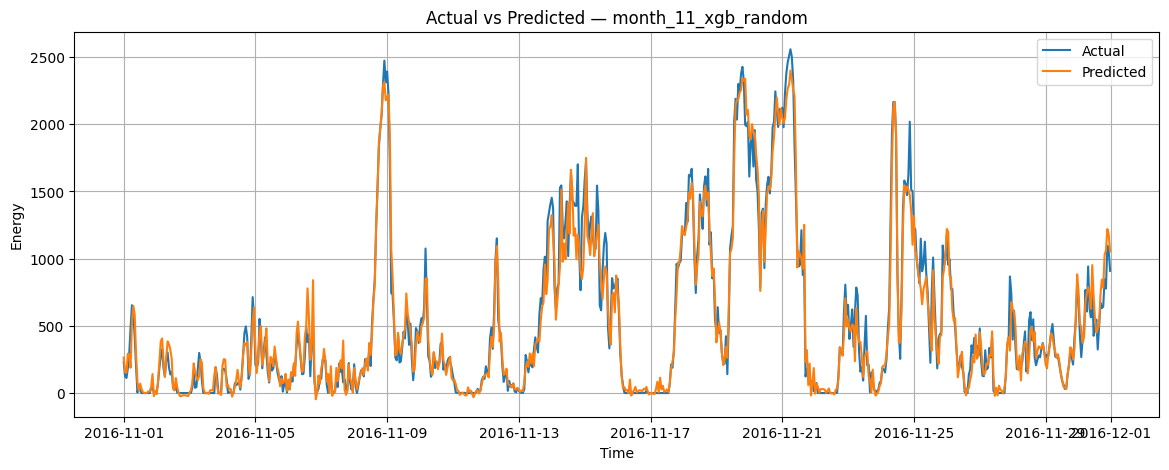

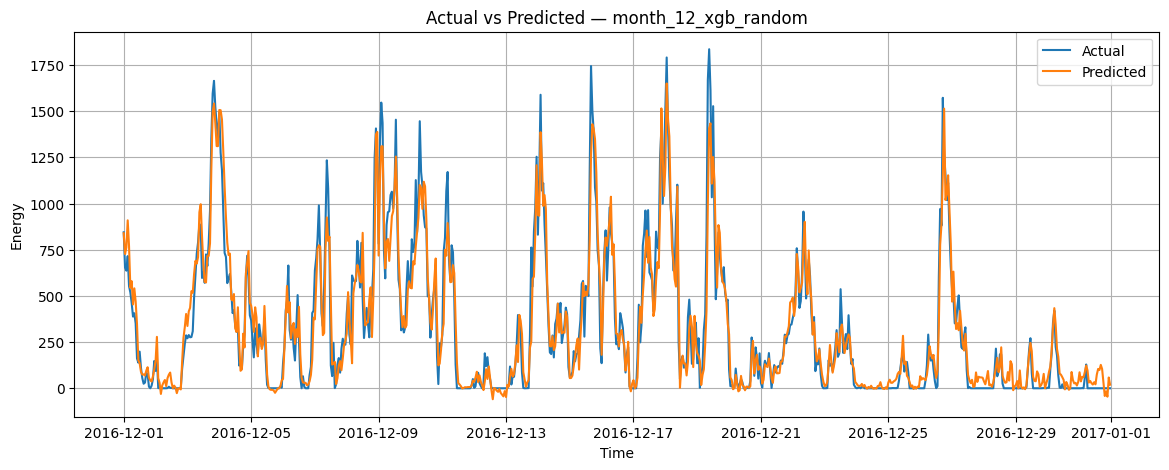

In [21]:
# ============================================================
# CELL 19 — VISUALISASI HASIL PREDIKSI
# ============================================================

for key, pred_df in predictions_store.items():
    plt.figure(figsize=(14, 5))
    plt.plot(pred_df["time"], pred_df["actual"], label="Actual")
    plt.plot(pred_df["time"], pred_df["predicted"], label="Predicted")
    plt.title(f"Actual vs Predicted — {key}")
    plt.xlabel("Time")
    plt.ylabel("Energy")
    plt.legend()
    plt.grid(True)
    plt.show()

Feature Importance — month_10


,Feature,Importance
6,hist_wind_speed,0.359147
13,energy_lag_1,0.356436
25,energy_roll_mean_3,0.191748
0,nwp_wind_speed,0.012223
7,hist_dir_sin,0.007951
2,nwp_dir_cos,0.006376
33,hist_wind_speed_roll_mean_3,0.004942
19,hist_wind_speed_lag_1,0.004754
1,nwp_dir_sin,0.004147
3,nwp_temp,0.004055


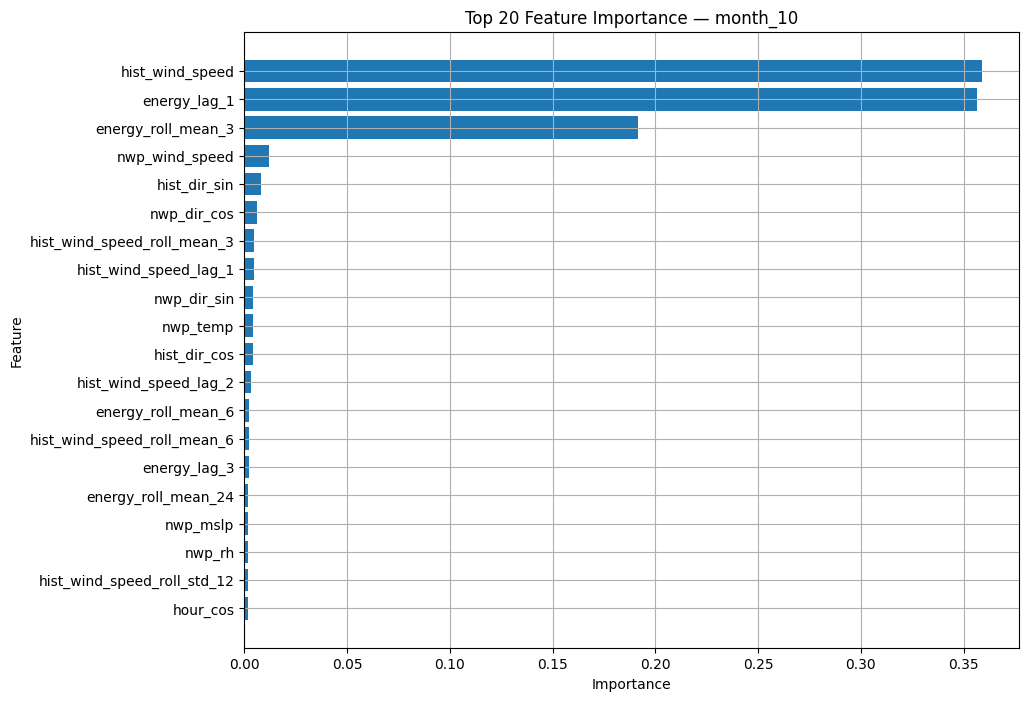

Feature Importance — month_11


,Feature,Importance
13,energy_lag_1,0.343294
6,hist_wind_speed,0.339540
25,energy_roll_mean_3,0.183468
0,nwp_wind_speed,0.021901
7,hist_dir_sin,0.008979
27,energy_roll_mean_6,0.006177
2,nwp_dir_cos,0.006174
19,hist_wind_speed_lag_1,0.005840
14,energy_lag_2,0.005315
8,hist_dir_cos,0.005148


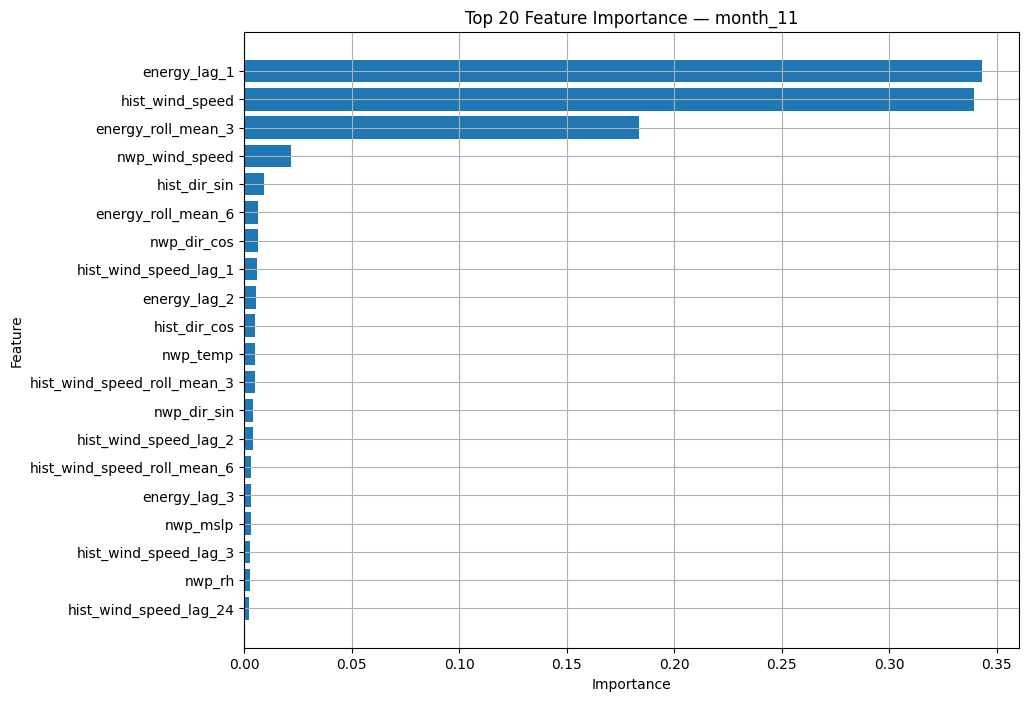

Feature Importance — month_12


,Feature,Importance
13,energy_lag_1,0.400014
6,hist_wind_speed,0.289520
25,energy_roll_mean_3,0.187793
0,nwp_wind_speed,0.017022
7,hist_dir_sin,0.008093
14,energy_lag_2,0.006745
27,energy_roll_mean_6,0.006066
2,nwp_dir_cos,0.005615
33,hist_wind_speed_roll_mean_3,0.005355
19,hist_wind_speed_lag_1,0.005265


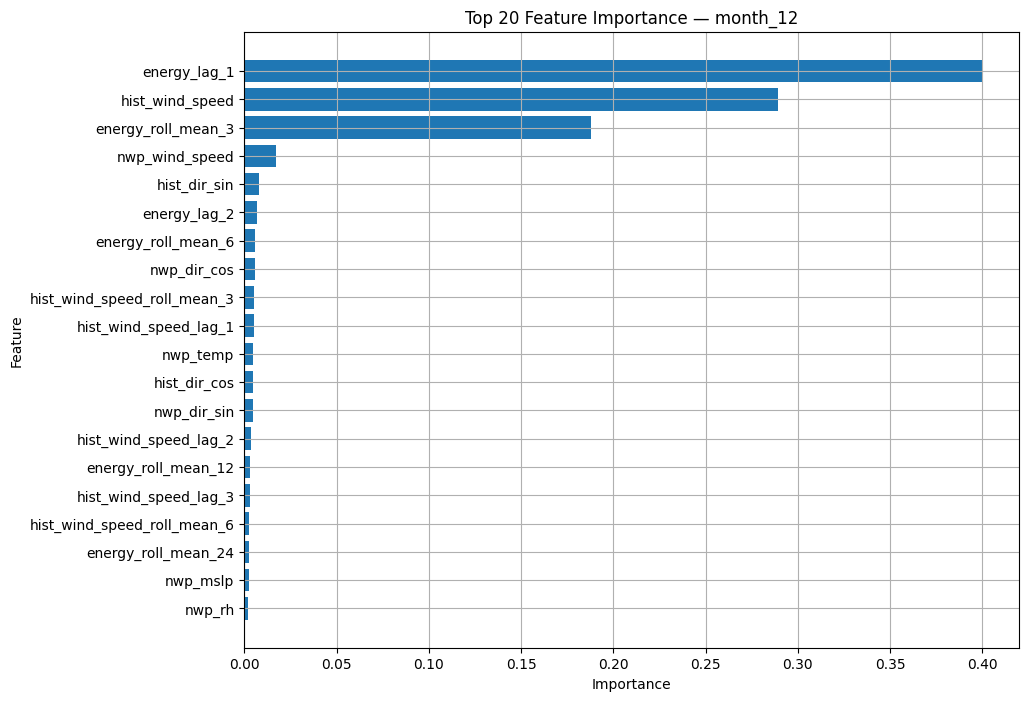

In [22]:
# ============================================================
# CELL 20 — FEATURE IMPORTANCE MODEL TERBAIK
# ============================================================

# Menampilkan feature importance dari model RandomizedSearchCV
# Untuk masing-masing bulan uji

for key, model in best_models.items():
    importance_df = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False)

    print("=" * 80)
    print(f"Feature Importance — {key}")
    display(importance_df.head(20))

    plt.figure(figsize=(10, 8))
    top_imp = importance_df.head(20).sort_values("Importance", ascending=True)
    plt.barh(top_imp["Feature"], top_imp["Importance"])
    plt.title(f"Top 20 Feature Importance — {key}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.grid(True)
    plt.show()